In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr

from src.constants import INSAMPLE_START, INSAMPLE_END, SIGNAL_HORIZON_DAYS

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

raw = pd.read_parquet('../data/funding_rates.parquet')
raw.index = raw.index.floor('h')
funding_all = raw[~raw.index.duplicated(keep='last')].sort_index()

# In-sample only — never touch backtest data during calibration
funding = funding_all.loc[INSAMPLE_START:INSAMPLE_END]

# Filter to coins with full in-sample coverage (drop coins listed mid-window)
min_obs = int(0.95 * len(funding))
funding = funding.loc[:, funding.notna().sum() >= min_obs]

HORIZON_H = SIGNAL_HORIZON_DAYS * 24  # forecast horizon in hours

print(f'In-sample: {funding.index[0].date()} → {funding.index[-1].date()}')
print(f'Coins with ≥95% coverage: {len(funding.columns)}: {list(funding.columns)}')
print(f'Signal horizon: {SIGNAL_HORIZON_DAYS}d ({HORIZON_H}h)')

In-sample: 2024-05-01 → 2025-09-01
Coins with ≥95% coverage: 15: ['BTC', 'ETH', 'SOL', 'DOGE', 'XRP', 'TAO', 'AAVE', 'SUI', 'APE', 'BNB', 'ADA', 'ZRO', 'LINK', 'ARB', 'LDO']
Signal horizon: 7d (168h)


## 1. EWMA Signals

For each coin, compute exponentially-weighted moving averages at different half-lives.
The signal is the EWMA value at time t; we evaluate how well it predicts the actual funding rate at t+h.

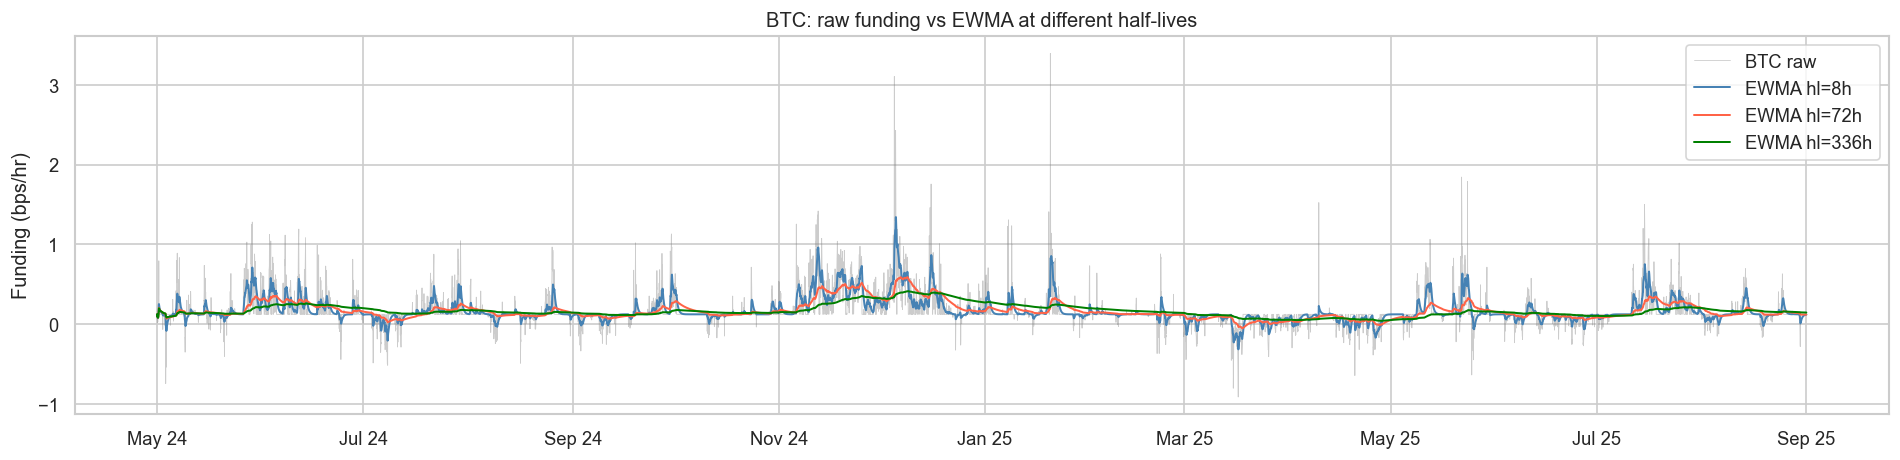

In [8]:
HALF_LIVES_H = [8, 24, 72, 168, 336]  # hours: 8h, 1d, 3d, 1w, 2w

ewma_signals = {
    hl: funding.ewm(halflife=hl).mean()
    for hl in HALF_LIVES_H
}

# Spot check: BTC EWMA vs raw
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(funding.index, funding['BTC'] * 1e4, lw=0.5, alpha=0.4, color='gray', label='BTC raw')
for hl, color in zip([8, 72, 336], ['steelblue', 'tomato', 'green']):
    ax.plot(ewma_signals[hl].index, ewma_signals[hl]['BTC'] * 1e4,
            lw=1.2, label=f'EWMA hl={hl}h', color=color)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.set_ylabel('Funding (bps/hr)')
ax.set_title('BTC: raw funding vs EWMA at different half-lives')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
def compute_ic_series(signal: pd.DataFrame, realized: pd.DataFrame) -> pd.Series:
    """Spearman IC at each timestamp across coins."""
    common = signal.index.intersection(realized.index)
    s = signal.loc[common]
    r = realized.loc[common]
    ics = []
    idx_out = []
    for t in common:
        sv = s.loc[t].dropna()
        rv = r.loc[t].reindex(sv.index).dropna()
        sv = sv.reindex(rv.index)
        if len(rv) < 5:
            continue
        ic, _ = spearmanr(sv, rv)
        if not np.isnan(ic):
            ics.append(ic)
            idx_out.append(t)
    return pd.Series(ics, index=idx_out)


# Target: cumulative funding over the next HORIZON_H hours (what we actually earn by holding)
# Lag by 1 additional hour to avoid any data leakage
realized_cumulative = funding.shift(-(HORIZON_H + 1)).rolling(HORIZON_H).sum()

EVAL_HORIZONS = [HORIZON_H]  # primary horizon; expand below for IC decay
ic_results = {}
for hl in HALF_LIVES_H:
    ic_results[hl] = compute_ic_series(ewma_signals[hl], realized_cumulative)

rows = []
for hl, ic in ic_results.items():
    rows.append({
        'Half-life (h)': hl,
        'Forecast horizon': f'{SIGNAL_HORIZON_DAYS}d',
        'Mean IC': ic.mean(),
        'IC Std': ic.std(),
        'IC IR': ic.mean() / ic.std() if ic.std() > 0 else np.nan,
        'Hit Rate': (ic > 0).mean(),
        'N': len(ic),
    })

summary = pd.DataFrame(rows).set_index('Half-life (h)')
display(summary.style.format({
    'Mean IC': '{:.4f}', 'IC Std': '{:.4f}', 'IC IR': '{:.4f}', 'Hit Rate': '{:.3f}'
}).background_gradient(subset=['Mean IC', 'IC IR'], cmap='RdYlGn'))

,Forecast horizon,Mean IC,IC Std,IC IR,Hit Rate,N
Half-life (h),,,,,,
8,7d,0.5882,0.2095,2.8072,0.985,11376
24,7d,0.6005,0.2043,2.9391,0.986,11376
72,7d,0.6059,0.2067,2.9318,0.994,11376
168,7d,0.6069,0.2028,2.9923,0.995,11376
336,7d,0.5964,0.2036,2.9291,0.992,11376


## 3. AR(1) Signal

Fit a rolling OLS regression: funding_{t+1} ~ funding_t (per coin).
The predicted value is the AR(1) forecast of next-period funding.

In [10]:
print(f'Computing direct {SIGNAL_HORIZON_DAYS}d regression forecasts (rolling window)...')

ROLL_WINDOW = 24 * 30  # 30-day rolling estimation window in hours

def direct_forecast(series: pd.Series, target: pd.Series, window: int) -> pd.Series:
    """Rolling direct regression: cumulative_funding_{t→t+H} ~ funding_t.
    Predicts the H-day cumulative target directly rather than iterating 1h-ahead AR(1),
    which would compound errors over a 72h horizon."""
    f = series.values
    t = target.values
    preds = np.full(len(f), np.nan)
    for i in range(window, len(f)):
        x = f[i - window : i]
        y = t[i - window : i]
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 10:
            continue
        xm, ym = x[mask], y[mask]
        b = np.cov(xm, ym)[0, 1] / (np.var(xm) + 1e-12)
        a = ym.mean() - b * xm.mean()
        preds[i] = a + b * f[i]
    return pd.Series(preds, index=series.index)

direct_signal = pd.DataFrame({
    coin: direct_forecast(funding[coin], realized_cumulative[coin].shift(), ROLL_WINDOW)
    for coin in funding.columns
})
print('Done.')

direct_ic = compute_ic_series(direct_signal, realized_cumulative)
print(f'\nDirect regression → {SIGNAL_HORIZON_DAYS}d cumulative funding:')
print(f'  Mean IC: {direct_ic.mean():.4f}')
print(f'  IC IR:   {direct_ic.mean() / direct_ic.std():.4f}')
print(f'  Hit Rate:{(direct_ic > 0).mean():.3f}')

Computing direct 7d regression forecasts (rolling window)...
Done.

Direct regression → 7d cumulative funding:
  Mean IC: 0.6643
  IC IR:   3.5235
  Hit Rate:0.999


In [14]:
# Pick the two EWMA half-lives with highest IC at the primary horizon
ic_mean = summary['Mean IC'].sort_values(ascending=False)
top_hls = ic_mean.head(2).index.tolist()
print(f'Top EWMA half-lives: {top_hls}h')

components = [ewma_signals[hl] for hl in top_hls] + [direct_signal]
composite = sum(components) / len(components)

comp_ic = compute_ic_series(composite, realized_cumulative)
print(f'\nComposite → {SIGNAL_HORIZON_DAYS}d cumulative funding:')
print(f'  Mean IC: {comp_ic.mean():.4f}')
print(f'  IC IR:   {comp_ic.mean() / comp_ic.std():.4f}')
print(f'  Hit Rate:{(comp_ic > 0).mean():.3f}')

Top EWMA half-lives: [168, 72]h

Composite → 7d cumulative funding:
  Mean IC: 0.6644
  IC IR:   3.5227
  Hit Rate:0.999


## 4. Save Composite Signal

In [15]:
composite.to_parquet('../data/composite_signal.parquet')
print('Saved data/composite_signal.parquet')
print(f'Shape: {composite.shape}')

Saved data/composite_signal.parquet
Shape: (11712, 15)
